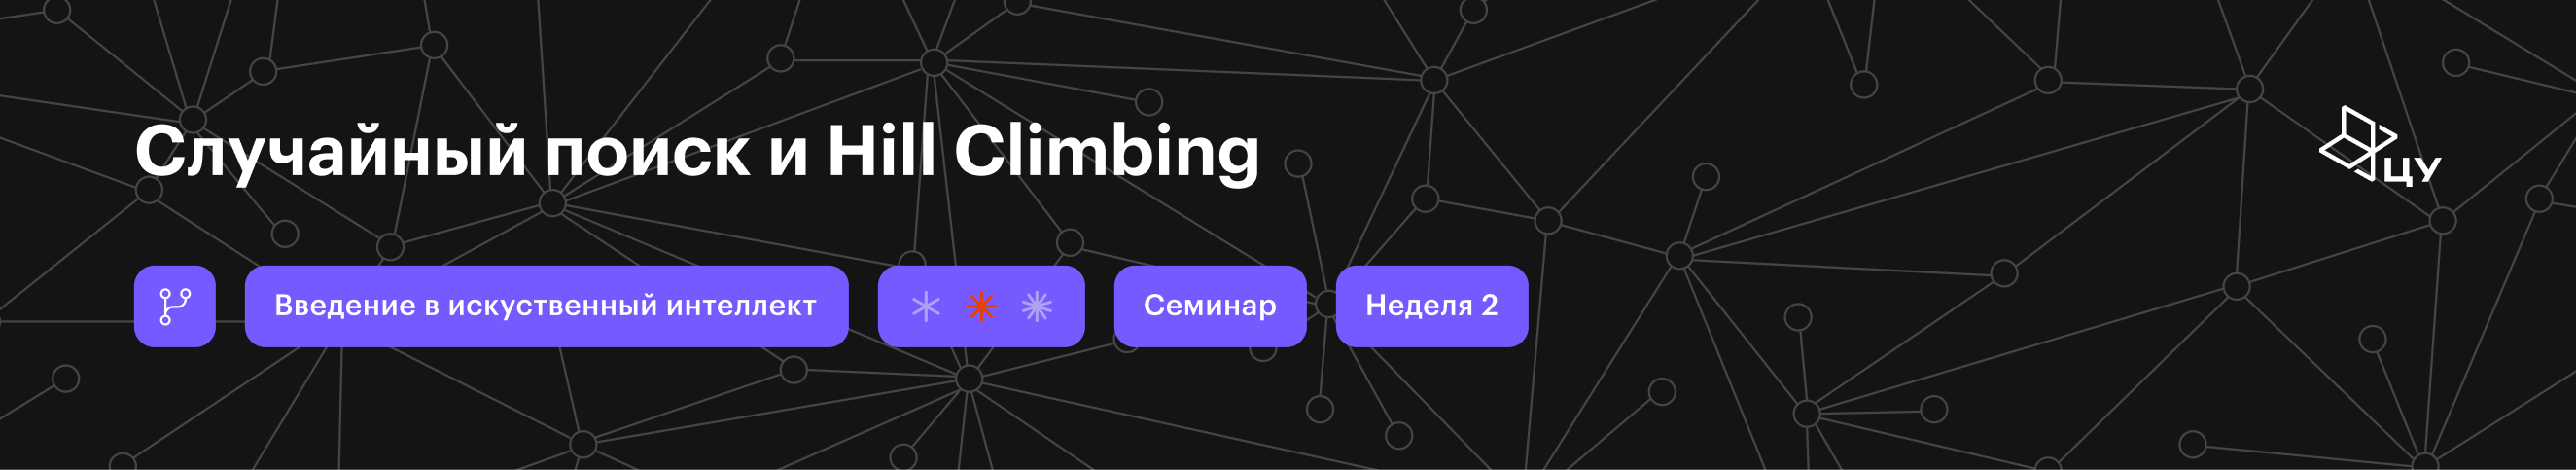

# Семинар по теме «Случайный поиск и Hill Climbing»

Сегодня мы рассмотрим два простых алгоритма поиска решения — **случайный поиск** и **Hill Climbing** — на задаче о $n$ ферзях, а затем перенесём идею случайного поиска на задачу численной оптимизации функций.

Из этого семинара ты узнаешь:

- как представить расстановку ферзей в виде вектора;
- как формально измерить качество расстановки;
- чем случайное блуждание отличается от Hill Climbing;
- почему Hill Climbing может застрять в локальном минимуме;
- как реализовать случайный поиск минимума функции.

In [1]:
# Бебебе (＃￣ω￣), импорты и общие настройки
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.grid": True,
})

SEED = 42

## Задача о $n$ ферзях

Нужно поставить $n$ ферзей на шахматную доску $n \times n$ так, чтобы никакие два ферзя не били друг друга.

Ферзь бьёт по горизонтали, вертикали и диагонали.

Чтобы не проверять вертикальные конфликты, заранее считаем, что **в каждом столбце стоит ровно один ферзь**. Тогда расстановку удобно хранить в виде списка

```python
state = [r_0, r_1, ..., r_{n-1}]
```

где `state[c]` — номер строки, в которой находится ферзь из столбца `c`.

Например, `[2, 0, 3, 1]` задаёт четыре ферзя в строках 2, 0, 3 и 1 соответственно.

### Задание 1

Для двух ферзей с координатами $(r_1,c_1)$ и $(r_2,c_2)$ запиши условия, при которых они конфликтуют.

### Функция качества расстановки

Введём функцию

$$
h(s)=\sum_{0\le i<j<n}
\mathbb{I}\left[
r_i=r_j
\ \text{или}\
|r_i-r_j|=|i-j|
\right].
$$

То есть $h(s)$ — **число конфликтующих пар ферзей**.

- Чем меньше $h(s)$, тем лучше расстановка.
- Если $h(s)=0$, задача решена.
- Максимальное число конфликтующих пар равно $\binom{n}{2}$.

### Задание 2

Сколько конфликтов в расстановке

```python
state = [0, 0, 0, 0]
```

на доске $4\times4$?

### Задание 3

Реализуй функцию `count_conflicts(state)`, которая возвращает число конфликтующих пар.

In [2]:
def count_conflicts(state):
    n = len(state)
    conflicts = 0
    for c1 in range(n):
        for c2 in range(c1 + 1, n):
    # TODO: перебери все пары столбцов c1 < c2 и посчитай число конфликтов
          r1 = state[c1]
          r2 = state[c2]

          same_row = r1 == r2

          same_diagonal = abs(r1 - r2) == abs(c1 - c2)

          if same_row or same_diagonal:
            conflicts += 1
    return conflicts

In [3]:
# @title Визуализация шахматной доски (служебный код)

def draw_board(state, ax=None, title=None):
    """Рисует расстановку, заданную номерами строк ферзей."""
    state = np.asarray(state, dtype=int)
    n = len(state)

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    for row in range(n):
        for col in range(n):
            shade = 0.92 if (row + col) % 2 == 0 else 0.58
            ax.add_patch(
                Rectangle(
                    (col, n - 1 - row),
                    1,
                    1,
                    facecolor=str(shade),
                    edgecolor="white",
                    linewidth=0.8,
                )
            )

    for col, row in enumerate(state):
        ax.text(
            col + 0.5,
            n - 1 - row + 0.5,
            "♛",
            ha="center",
            va="center",
            fontsize=max(18, 34 - n),
            fontfamily="DejaVu Sans",
        )

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(n) + 0.5, labels=np.arange(1, n + 1))
    ax.set_yticks(np.arange(n) + 0.5, labels=np.arange(n, 0, -1))
    ax.tick_params(length=0)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    if title is not None:
        ax.set_title(title)

    return ax

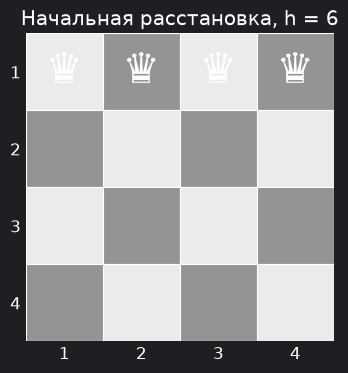

In [4]:
draw_board([0, 0, 0, 0], title="Начальная расстановка, h = 6")
plt.show()

## Случайный поиск на задаче о ферзях

В этом разделе под случайным поиском будем понимать **случайное блуждание по пространству расстановок**.

На каждом шаге алгоритм:

- случайно выбирает одного ферзя;
- случайно выбирает для него новую строку;
- перемещает ферзя независимо от того, стало решение лучше или хуже;
- останавливается, когда $h(s)=0$ или исчерпан лимит шагов.

У такого алгоритма нет направления движения. Он может случайно улучшить расстановку, затем ухудшить её, а потом снова улучшить.

Это одновременно является как недостатком (успех зависит от воли случая), так и достоинством (не нужно городить if if else else и думать над тем, как задать направление движения).

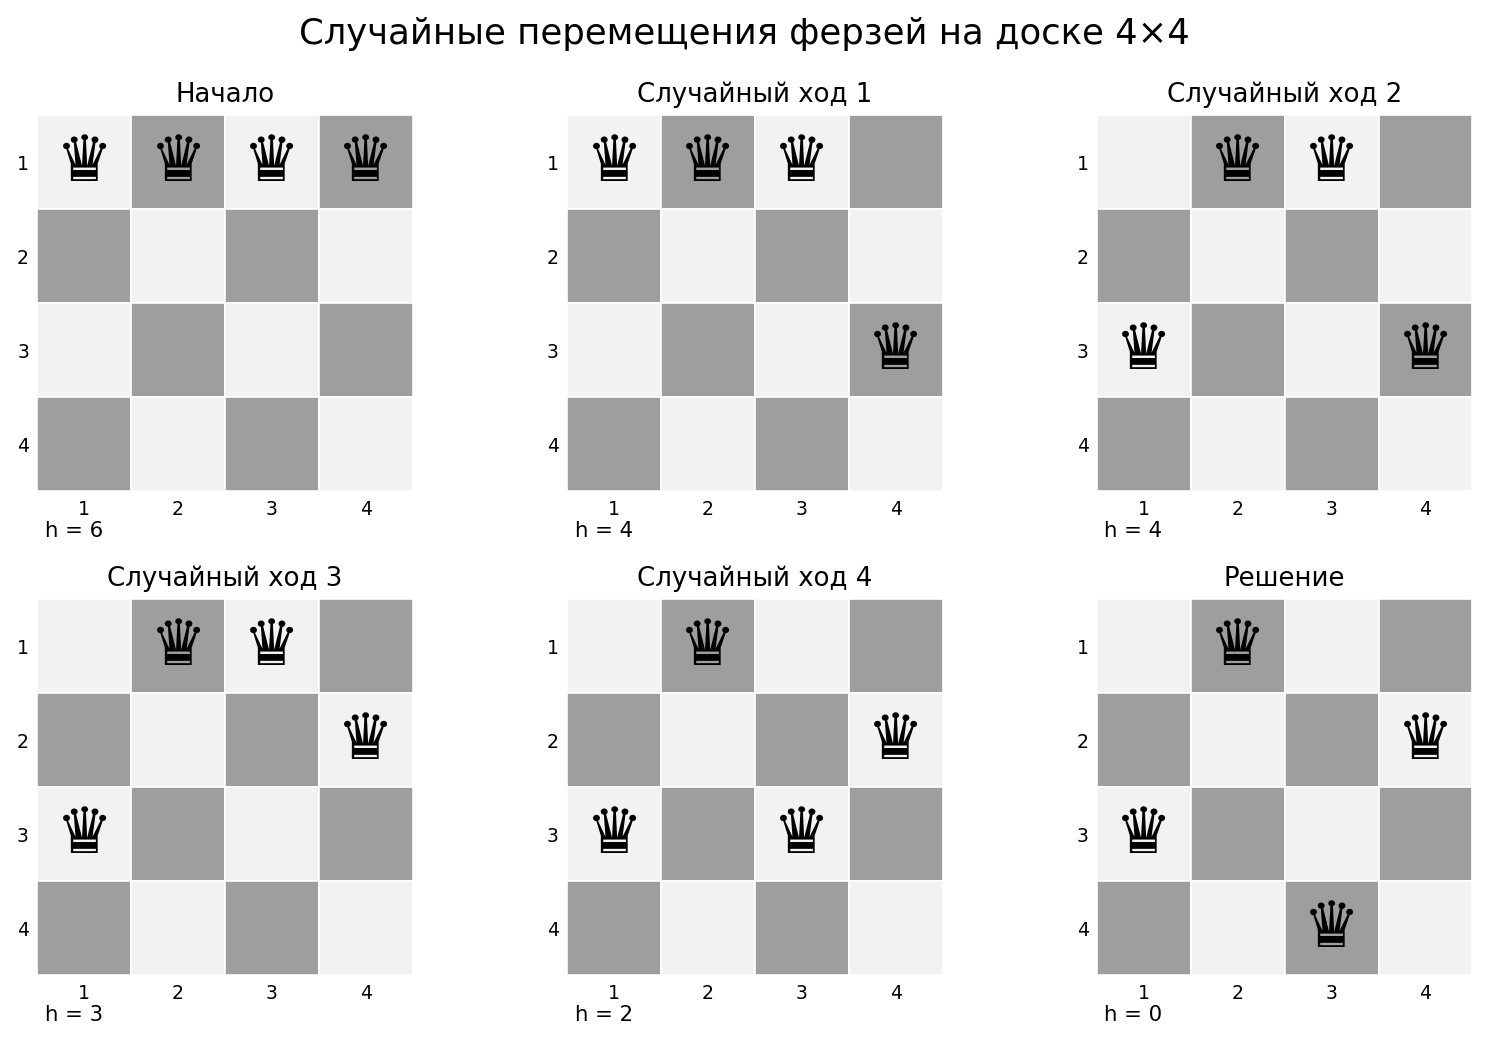

На рисунке показан один конкретный случайный путь:

```text
[0, 0, 0, 0] → [0, 0, 0, 2] → [2, 0, 0, 2]
→ [2, 0, 0, 1] → [2, 0, 2, 1] → [2, 0, 3, 1]
```

Значения функции качества:

```text
6 → 4 → 4 → 3 → 2 → 0
```



В этом запуске нам повезло: случайные движения привели к решению. Но алгоритм **не гарантирует**, что качество будет уменьшаться на каждом шаге.

### Задание 4

Гарантированно ли данный алгоритм достигнет решения?

### Задание 5

Реализуй функцию `random_neighbor(state, rng)`, которая:

- случайно выбирает столбец;
- переносит находящегося в нём ферзя в другую случайную строку;
- возвращает новую расстановку;
- не изменяет исходный список.

In [5]:
def random_neighbor(state, rng):
    """Возвращает случайного соседа расстановки"""
    state = np.asarray(state, dtype=int)
    n = len(state)

    column = rng.integers(0, n)
    possible_rows = np.delete(np.arange(n), state[column])
    new_row = rng.choice(possible_rows)

    neighbor = state.copy()
    neighbor[column] = new_row

    return neighbor


rng = np.random.default_rng(0)
print(random_neighbor([0, 0, 0, 0], rng))

[0 0 0 2]


### Задание 6

Реализуй случайный поиск `random_walk_n_queens`.

Функция должна возвращать:

- найденную расстановку;
- историю посещённых расстановок;
- флаг `success`, показывающий, найдено ли решение.

In [6]:
def random_walk_n_queens(initial_state, max_steps=10_000, seed=42):
    rng = np.random.default_rng(seed)

    state = np.asarray(initial_state, dtype=int).copy()

    history = [state]

    for _ in range(max_steps):
      if count_conflicts(state) == 0:

        return state, history, True

      state = random_neighbor(state, rng)
      history.append(state.copy())

    success = count_conflicts(state) == 0

    return state, history, success

### Задание 7

Почему по одному удачному запуску нельзя сделать вывод, что случайный поиск работает быстро?

In [7]:
# @title Эксперимент: 100 запусков случайного поиска

steps = []
successes = 0

for seed in range(100):
    _, run_history, run_success = random_walk_n_queens(
        [0, 0, 0, 0, 0, 0, 0, 0],
        max_steps=2000,
        seed=seed,
    )

    successes += int(run_success)

    if run_success:
        steps.append(len(run_history) - 1)

print(f"Успешных запусков: {successes}/100")

if steps:
    print(f"Медианное число шагов: {np.median(steps):.0f}")
    print(f"Среднее число шагов: {np.mean(steps):.1f}")

    plt.hist(steps, bins=15)
    plt.xlabel("число случайных ходов")
    plt.ylabel("число запусков")
    plt.title("Сколько шагов потребовалось случайному поиску")
    plt.show()

Успешных запусков: 0/100


### Задание 8

Сделай несколько запусков данного эксперимента с разными параметрами. Какие выводы можно сделать о случайном спуске? Как параметры влияют на распределение?

## Hill Climbing

Случайный поиск не использует информацию о качестве соседних состояний.

**Hill Climbing** действует более осмысленно:

- строит соседние  (расстановки, в которые можно прийти за 1 ход);
- вычисляет их качество;
- выбирает лучшего соседа;
- переходит в него, только если качество строго улучшилось;
- останавливается при достижении $h(s)=0$ или отсутствии улучшающего хода.

Хотя метод называется *подъёмом на холм*, мы минимизируем число конфликтов. Поэтому фактически движемся вниз по поверхности функции $h$.

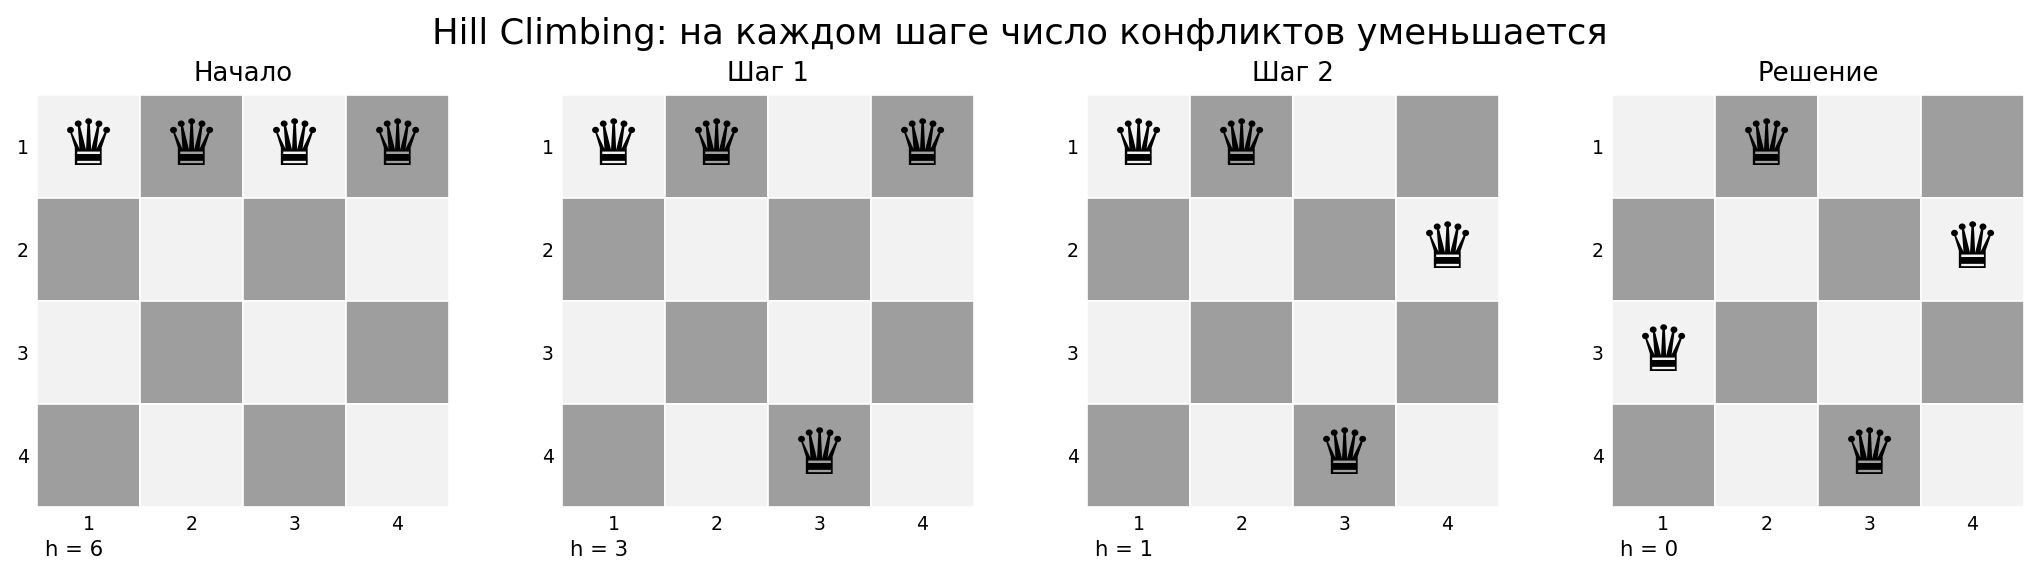

Для показанного пути:

```text
[0, 0, 0, 0] → [0, 0, 3, 0] → [0, 0, 3, 1] → [2, 0, 3, 1]
```

получаем:

```text
h: 6 → 3 → 1 → 0
```

Теперь качество строго уменьшается на каждом шаге.

### Задание 9

Реализуй функцию `all_neighbors(state)`, возвращающую все расстановки, которые можно получить одним перемещением одного ферзя внутри его столбца.

Сколько соседей имеет любая расстановка при размере доски $n$?

In [8]:
def all_neighbors(state):
    """Возвращает все расстановки на расстоянии одного хода"""
    state = np.asarray(state, dtype=int)
    n = len(state)
    neighbors = []

    for column in range(n):
        for new_row in range(n):
            if new_row == state[column]:
                continue

            neighbor = state.copy()
            neighbor[column] = new_row
            neighbors.append(neighbor)

    return neighbors


print(len(all_neighbors([0, 0, 0, 0])))  # 4 * 3 = 12

12


### Задание 10

Реализуй функцию `best_neighbor(state)`, возвращающую:

- лучшего соседа;
- значение $h$ для этого соседа.

Если лучших соседей несколько, можно вернуть любого из них.

In [9]:
def best_neighbor(state):
    """Находит соседа с минимальным числом конфликтов"""
    neighbors = all_neighbors(state)
    scores = np.array([count_conflicts(x) for x in neighbors])

    best_index = np.argmin(scores)

    return neighbors[best_index], int(scores[best_index])

### Задание 11

Собери полный алгоритм Hill Climbing.

Остановись, если:

- найдено решение;
- лучший сосед не лучше текущего состояния;
- достигнуто ограничение `max_steps`.

In [10]:
def hill_climbing(initial_state, max_steps=1_000):
    state = np.asarray(initial_state, dtype=int).copy()
    rng = np.random.default_rng(seed)
    history = [state]

    for _ in range(max_steps):
      current_score = count_conflicts(state)

      if count_conflicts == 0:
        return state, history, True

      candidate, candidate_score = best_neighbor(state)

      if candidate_score < current_score:
        return state, history, False
      history.append
      state = candidate

    success = best_neighbor(state) == 0
    return state, history, success

## Когда Hill Climbing застревает

Рассмотрим расстановку

```python
state = [0, 2, 3, 1]
```

В ней есть ровно один конфликт:

$$
h(s)=1.
$$

Однако ни одно перемещение одного ферзя не уменьшает значение $h$.

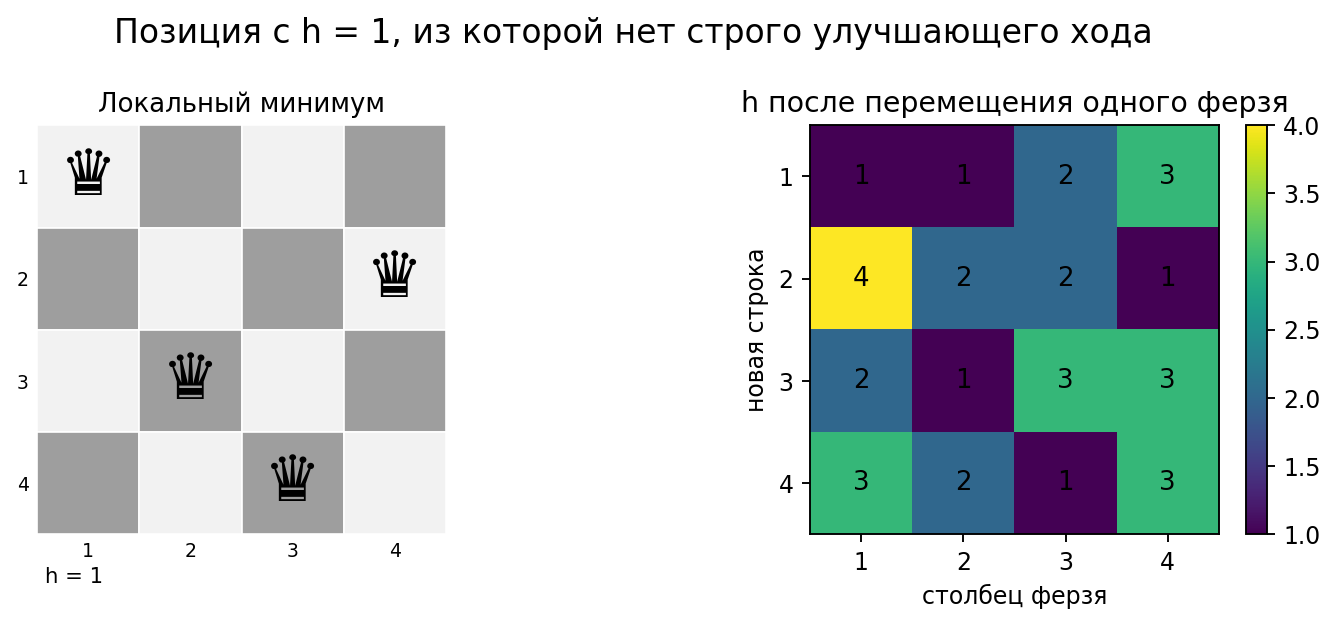

В правой части рисунка записано, каким станет число конфликтов после переноса выбранного ферзя в выбранную строку.

Минимальное значение среди соседей равно текущему:

$$
\min_{s'\in N(s)}h(s')=1=h(s).
$$

Поэтому Hill Climbing со **строгим улучшением** остановится.

Важно сформулировать результат точно.

> Правильная расстановка недостижима из этой позиции не вообще, а при условии, что алгоритм разрешает только ходы со строгим уменьшением $h$.

Если разрешить временно сохранить или увеличить число конфликтов, из этой позиции можно уйти.

### Задание 12

Как называются такие позиции? Какие изменения алгоритма помогают из них выходить?

In [11]:
# Проверим локальный минимум программно

trap_state = np.array([0, 2, 3, 1])
neighbor_scores = [
    count_conflicts(neighbor)
    for neighbor in all_neighbors(trap_state)
]

print("Текущее h:", count_conflicts(trap_state))
print("Лучшее h среди соседей:", min(neighbor_scores))

result, trap_history, success = hill_climbing(trap_state)

print("Успех:", success)
print("Число сделанных ходов:", len(trap_history) - 1)

Текущее h: 1
Лучшее h среди соседей: 1
Успех: False
Число сделанных ходов: 0


### Задание 13

Реализуй Hill Climbing со случайными перезапусками.

Алгоритм должен:

- случайно генерировать начальную расстановку;
- запускать обычный Hill Climbing;
- возвращать решение при первом успехе;
- завершаться после `n_restarts` неудачных попыток.

In [12]:
def random_restart_hill_climbing(n, n_restarts=100, seed=42):
    """Hill Climbing с независимыми случайными перезапусками"""
    rng = np.random.default_rng(seed)

    for restart in range(n_restarts):
        initial_state = rng.integers(0, n, size=n)
        solution, history, success = hill_climbing(initial_state)

        if success:
            return {
                "solution": solution,
                "history": history,
                "success": True,
                "restart": restart,
            }

    return {
        "solution": None,
        "history": None,
        "success": False,
        "restart": n_restarts,
    }


result = random_restart_hill_climbing(
    n=5,
    n_restarts=1_000,
    seed=4,
)

print("Успех:", result["success"])
print("Номер успешного перезапуска:", result["restart"])
print("Решение:", result["solution"])

Успех: False
Номер успешного перезапуска: 1000
Решение: None


## Переход к оптимизации функций

Теперь забудем на время о шахматной доске.

Пусть задана функция

$$
f:\mathbb{R}^d\to\mathbb{R},
$$

и требуется найти точку

$$
x^\star=\arg\min_{x\in D}f(x).
$$

Обычный случайный поиск не строит соседей, а независимо генерирует точки из области $D$ и запоминает лучшую. Попробуем применить данный метод к непрерывной задаче.

### Алгоритм случайного поиска

Пусть область поиска — многомерный кубик

$$
D=[l_1,u_1]\times\ldots\times[l_d,u_d].
$$

Например, при d = 1 D — это отрезок, при d = 2 — прямоугольник, при d = 3 — параллелепипед и так далее.

Алгоритм:

- сгенерировать случайную точку $x_1\in D$;
- вычислить $f(x_1)$;
- повторить генерацию точек $x_2, \ldots, x_N$;
- вернуть точку с минимальным найденным значением функции.

Псевдокод:

```text
best_x = None
best_value = +∞

повторить N раз:
    x = случайная точка из D
    value = f(x)

    если value < best_value:
        best_x = x
        best_value = value

вернуть best_x, best_value
```

### Задание 14

Реализуй функцию `sample_point(bounds, rng)`.

Аргумент `bounds` имеет вид:

```python
bounds = [
    (left_1, right_1),
    (left_2, right_2),
    ...
]
```

Функция должна равномерно генерировать одну точку внутри прямоугольной области.

In [13]:
def sample_point(bounds, rng):
    """Равномерно генерирует точку в прямоугольной области"""
    bounds = np.asarray(bounds, dtype=float)

    left = bounds[:, 0]
    right = bounds[:, 1]

    return rng.uniform(left, right)


rng = np.random.default_rng(42)
print(sample_point([(-5, 5), (0, 2)], rng))

[2.73956049 0.87775688]


### Задание 15

Реализуй один шаг обновления лучшего найденного решения.

Функция `update_best` получает текущие `best_x`, `best_value`, новую точку `x` и значение `value`.

In [14]:
def update_best(best_x, best_value, x, value):
    """Обновляет рекорд, если новая точка оказалась лучше"""
    if value < best_value:
        return np.asarray(x).copy(), float(value)

    return best_x, best_value

### Задание 16

Собери полный алгоритм `random_search`.

Он должен возвращать словарь:

```python
{
    "best_x": ...,
    "best_value": ...,
    "points": ...,
    "values": ...,
    "best_history": ...,
}
```

`best_history[k]` — лучшее значение функции, найденное к моменту шага `k`.

In [15]:
def random_search(objective, bounds, n_iter=1_000, seed=42):
    """Ищет минимум функции независимым случайным семплированием"""
    if n_iter <= 0:
        raise ValueError("n_iter должно быть положительным")

    rng = np.random.default_rng(seed)

    points = []
    values = []
    best_history = []

    best_x = None
    best_value = np.inf

    for _ in range(n_iter):
        x = sample_point(bounds, rng)
        value = float(objective(x))

        points.append(x)
        values.append(value)

        best_x, best_value = update_best(
            best_x,
            best_value,
            x,
            value,
        )
        best_history.append(best_value)

    return {
        "best_x": np.asarray(best_x),
        "best_value": best_value,
        "points": np.asarray(points),
        "values": np.asarray(values),
        "best_history": np.asarray(best_history),
    }

## Тестирование на простых функциях

Начнём с функций, для которых точный минимум известен заранее.

### Функция 1

$$
f_1(x)=x^2,\qquad x\in[-5,5].
$$

Точный минимум:

$$
x^\star=0,\qquad f_1(x^\star)=0.
$$

### Функция 2

$$
f_2(x)=(x-2)^2+1,\qquad x\in[-5,5].
$$

Точный минимум:

$$
x^\star=2,\qquad f_2(x^\star)=1.
$$

### Задание 17

Запиши функции `quadratic` и `shifted_quadratic` так, чтобы они принимали вектор `x`, как ожидает `random_search`.

In [16]:
def quadratic(x):
    return x[0] ** 2


def shifted_quadratic(x):
    return (x[0] - 2) ** 2 + 1

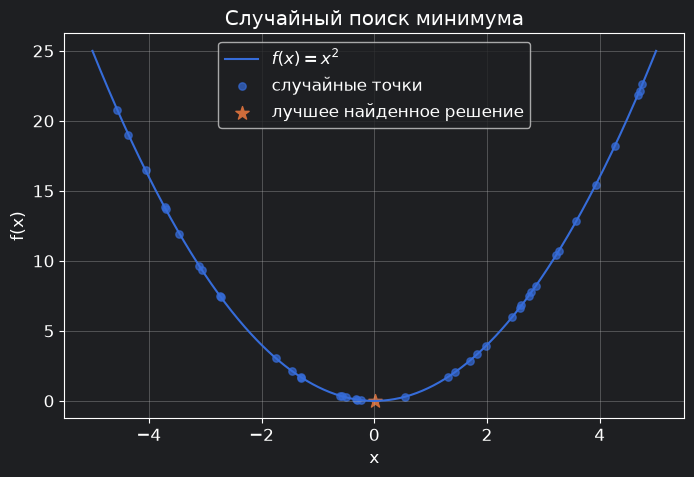

In [17]:
# Запускаем поиск на двух одномерных функциях

result_1 = random_search(
    quadratic,
    bounds=[(-5, 5)],
    n_iter=1_000,
    seed=42,
)
x_grid = np.linspace(-5, 5, 500)
y_grid = x_grid ** 2

shown = 40
sample_x = result_1["points"][:shown, 0]
sample_y = result_1["values"][:shown]

plt.plot(x_grid, y_grid, label=r"$f(x)=x^2$")
plt.scatter(sample_x, sample_y, s=28, alpha=0.7, label="случайные точки")
plt.scatter(
    result_1["best_x"][0],
    result_1["best_value"],
    s=100,
    marker="*",
    label="лучшее найденное решение",
)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Случайный поиск минимума")
plt.legend()
plt.show()

### Задание 18

Что произойдёт с `best_history` при увеличении номера итерации?

Может ли лучшее найденное значение стать хуже?

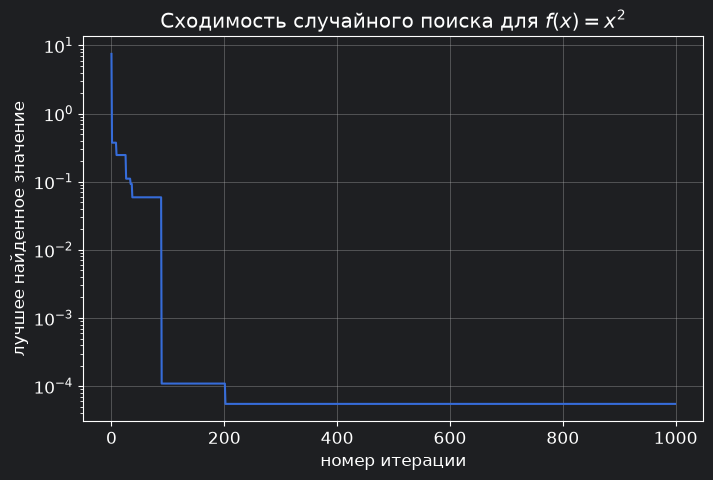

In [18]:
# @title График сходимости

plt.plot(result_1["best_history"])
plt.yscale("log")
plt.xlabel("номер итерации")
plt.ylabel("лучшее найденное значение")
plt.title(r"Сходимость случайного поиска для $f(x)=x^2$")
plt.show()

## Двумерная функция

Рассмотрим функцию:

$$
f(x_1,x_2)=x_1^2+x_2^2.
$$

Её глобальный минимум находится в точке $(0,0)$.

### Задание 19

Реализуй функцию `sphere(x)` для произвольной размерности.

In [19]:
def sphere(x):
    x = np.asarray(x)
    return np.sum(x ** 2)

In [20]:
sphere_result = random_search(
    sphere,
    bounds=[(-5, 5), (-5, 5)],
    n_iter=2_000,
    seed=42,
)

print("Лучшая точка:", sphere_result["best_x"])
print("Лучшее значение:", sphere_result["best_value"])

Лучшая точка: [0.02874937 0.05276922]
Лучшее значение: 0.0036111171528374585


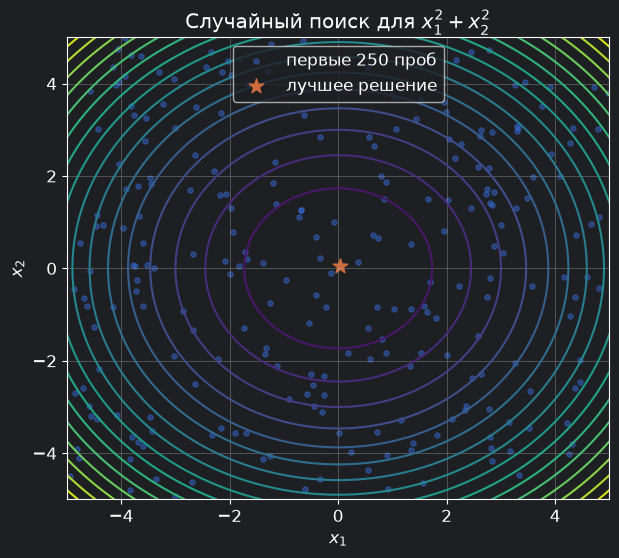

In [21]:
# @title Случайный поиск на линиях уровня двумерной функции

axis = np.linspace(-5, 5, 300)
x1, x2 = np.meshgrid(axis, axis)
z = x1 ** 2 + x2 ** 2

plt.figure(figsize=(7, 6))
plt.contour(x1, x2, z, levels=18)

shown_points = sphere_result["points"][:250]
plt.scatter(
    shown_points[:, 0],
    shown_points[:, 1],
    s=14,
    alpha=0.45,
    label="первые 250 проб",
)
plt.scatter(
    sphere_result["best_x"][0],
    sphere_result["best_x"][1],
    s=120,
    marker="*",
    label="лучшее решение",
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Случайный поиск для $x_1^2+x_2^2$")
plt.legend()
plt.show()

## Более сложная функция: Rastrigin

Функция Растригина в размерности $d$:

$$
f(x)=10d+\sum_{i=1}^{d}
\left(x_i^2-10\cos(2\pi x_i)\right).
$$

Она имеет глобальный минимум

$$
x^\star=(0,\ldots,0),\qquad f(x^\star)=0,
$$

но вокруг него находится большое количество локальных минимумов.

Для случайного поиска локальные минимумы не являются непреодолимой ловушкой: алгоритм не движется по соседям, а независимо семплирует всю область. Но в большой размерности попасть близко к глобальному минимуму становится трудно.

### Задание 20

Реализуй функцию Растригина.

In [22]:
def rastrigin(x):
    x = np.asarray(x)
    d = len(x)

    return 10 * d + np.sum(
        x ** 2 - 10 * np.cos(2 * np.pi * x)
    )

In [23]:
rastrigin_result = random_search(
    rastrigin,
    bounds=[(-1.12, 1.12), (-1.12, 1.12)],
    n_iter=10_000,
    seed=42,
)

print("Лучшая точка:", rastrigin_result["best_x"])
print("Лучшее значение:", rastrigin_result["best_value"])

Лучшая точка: [0.00372253 0.0084142 ]
Лучшее значение: 0.01679168248448093


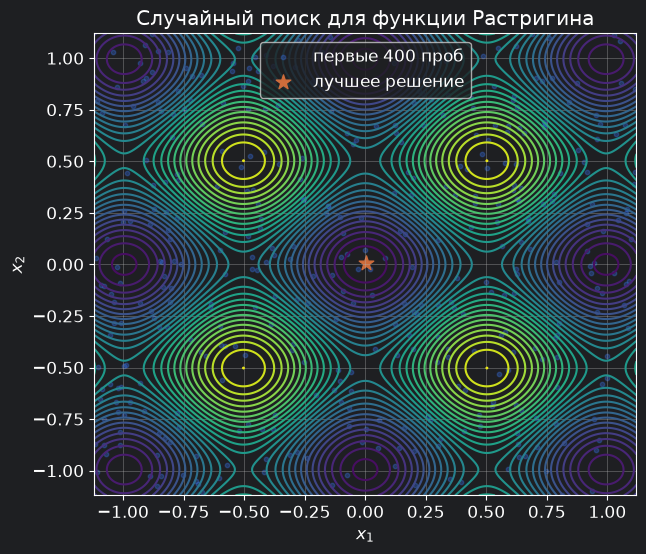

In [24]:
# @title Поверхность функции Растригина и найденные точки

axis = np.linspace(-1.12, 1.12, 400)
x1, x2 = np.meshgrid(axis, axis)
z = (
    20
    + x1 ** 2 - 10 * np.cos(2 * np.pi * x1)
    + x2 ** 2 - 10 * np.cos(2 * np.pi * x2)
)

plt.figure(figsize=(7, 6))
plt.contour(x1, x2, z, levels=35)

shown_points = rastrigin_result["points"][:400]
plt.scatter(
    shown_points[:, 0],
    shown_points[:, 1],
    s=10,
    alpha=0.35,
    label="первые 400 проб",
)
plt.scatter(
    rastrigin_result["best_x"][0],
    rastrigin_result["best_x"][1],
    s=120,
    marker="*",
    label="лучшее решение",
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Случайный поиск для функции Растригина")
plt.legend()
plt.show()


Исследуем влияние числа итераций.

Для значений

```python
n_iter_values = [10, 100, 1000, 5000, 10000, 50000]
```

запустим случайный поиск на функции сферы 30 раз с разными `seed`.

Для каждого `n_iter` вычисли медиану лучшего найденного значения.

In [25]:
n_iter_values = [10, 100, 1000, 5000, 10000, 50000]
median_scores = []

for n_iter in n_iter_values:
    run_scores = []

    for seed in range(30):
        result = random_search(
            sphere,
            bounds=[(-5, 5), (-5, 5)],
            n_iter=n_iter,
            seed=seed,
        )
        run_scores.append(result["best_value"])

    median_scores.append(np.median(run_scores))

for n_iter, score in zip(n_iter_values, median_scores):
    print(f"{n_iter:>6} итераций: median best = {score:.6f}")

    10 итераций: median best = 2.637915
   100 итераций: median best = 0.242170
  1000 итераций: median best = 0.028711
  5000 итераций: median best = 0.004026
 10000 итераций: median best = 0.003074
 50000 итераций: median best = 0.000352


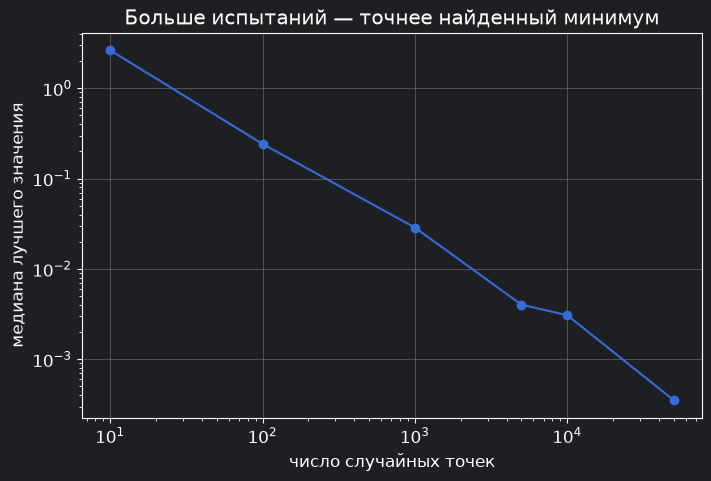

In [26]:
plt.plot(n_iter_values, median_scores, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("число случайных точек")
plt.ylabel("медиана лучшего значения")
plt.title("Больше испытаний — точнее найденный минимум")
plt.show()

### Задание 21

Почему случайный поиск быстро усложняется при росте размерности?

Например, если по каждой координате нужно попасть в интервал, занимающий десятую часть допустимого диапазона, какова вероятность одновременно попасть в нужный интервал по всем $d$ координатам?

Итак, сегодня мы:

Подробно изучили Hill Climbing

Попрактиковали Random Search

Изучили оптимизацию в дискретных и непрерывных задачах.


На следующей неделе мы попробуем перейти к качественно иным методам оптимизации, учтя "структуру" множества решений